# Performance testing of different methods of spherical polygon contains

These tests include using the ST `spherical_geometry` package --- which provides quad double precision.

The other core option is the built-in regions spherical polygon contains, which is double precision (as it leverages astropy.coordinates functions, which are double precision --- either directly through np trig calculations, or through the erfa ufuncs).

The various flavors consider the following:
1. **False**:
    * regions built-in spherical polygon contains
1. **poly**:
    * `spherical_geometry` contains. However, this includes a "pre-filtering" step when len(coord)>125, checking whether points are contained within a padded bounding circle (padded to ensure double precision errors don't interfere with the quad precision in `spherical_geometry`).
1. **optimize**:
    * Method depends on len(coord) and len(vertices).
        * Scalar coordinate uses the `spherical_geometry` contains.
        * If len(vertices) > len(coord), also use the `spherical_geometry` contains.
        * If len(coord) >= len(vertices), use the internal `spherical_geometry` arc intersection functions, but instead loop over the vertices (not over points).
1. **optimize_bounding_circle**:
    * The same as **optimize**, but performs a pre-filter checking whether points are contained within a padded bounding circle when len(coord)>125 (as in **poly**).
1. **optimize_fallback**:
    * The same as **optimize**, but when len(coord)>125, "falls back" to use the regions built-in polygon contains. This results in lower precision (double) for len(coord)>125.
1. **optimize_fallback_bounding_circle**:
    * The same as **optimize_fallback**, with the addition of also pre-filtering with a padded bounding circle when len(coord)>125 (as in **poly**).


Separate testing showed that the core unit calculation from `spherical_geometry`, `great_circle_arc.intersects()`, takes much longer than the internal calculations implemented in the regions spherical polygon. 

Furthermore, it appears the `spherical_geometry` calculations are performed with loops in the C++ code, explaining the N scaling of these methods. (However, I admit my understanding of raw C++ code and its python wrappers is limited.)

In [1]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
from regions import PolygonSphericalSkyRegion

import time
import datetime

import matplotlib.pyplot as plt

In [2]:
# Function for scaling:
def my_timeit(func, *args, **kwargs):
    start = time.time()
    # try:
    if True:
        result = func(*args, **kwargs)
        end = time.time()
        delta = datetime.timedelta(seconds=end-start)
    # except:
    #     result = None
    #     delta = None
    return delta, result

## Define polygons

In [3]:
poly = PolygonSphericalSkyRegion(SkyCoord([3, 3.5, 4, 3.5, 3] * u.deg,
                                              [3, 3.5, 4, 4, 4] * u.deg))

In [4]:
poly2 = poly.discretize_boundary(n_points=3)

In [5]:
poly3 = poly.discretize_boundary(n_points=10)

In [6]:
poly

<PolygonSphericalSkyRegion(vertices=<SkyCoord (ICRS): (ra, dec) in deg
    [(3. , 3. ), (3.5, 3.5), (4. , 4. ), (3.5, 4. ), (3. , 4. )]>)>

In [7]:
poly2

<PolygonSphericalSkyRegion(vertices=<SkyCoord (ICRS): (ra, dec) in deg
    [(3.        , 4.        ), (3.        , 3.66666667),
     (3.        , 3.33333333), (3.        , 3.        ),
     (3.16661208, 3.16669387), (3.3332778 , 3.33336101),
     (3.5       , 3.5       ), (3.66660359, 3.66669807),
     (3.83326931, 3.83336521), (4.        , 4.        ),
     (3.83333334, 4.00003374), (3.66666666, 4.00003374),
     (3.5       , 4.        ), (3.33333334, 4.00003374),
     (3.16666666, 4.00003374)]>)>

In [8]:
poly3

<PolygonSphericalSkyRegion(vertices=<SkyCoord (ICRS): (ra, dec) in deg
    [(3.        , 4.        ), (3.        , 3.9       ),
     (3.        , 3.8       ), (3.        , 3.7       ),
     (3.        , 3.6       ), (3.        , 3.5       ),
     (3.        , 3.4       ), (3.        , 3.3       ),
     (3.        , 3.2       ), (3.        , 3.1       ),
     (3.        , 3.        ), (3.04997816, 3.05001088),
     (3.09996097, 3.10001945), (3.1499485 , 3.15002566),
     (3.19994084, 3.20002948), (3.24993806, 3.25003087),
     (3.29994023, 3.30002979), (3.34994743, 3.3500262 ),
     (3.39995974, 3.40002006), (3.44997724, 3.45001134),
     (3.5       , 3.5       ), (3.54997472, 3.55001258),
     (3.59995486, 3.60002247), (3.64994048, 3.65002963),
     (3.69993167, 3.70003402), (3.7499285 , 3.7500356 ),
     (3.79993105, 3.80003433), (3.8499394 , 3.85003017),
     (3.89995363, 3.90002309), (3.9499738 , 3.95001304),
     (4.        , 4.        ), (3.95      , 4.00001366),
     (3.9       ,

## Random points: only some within region

In [9]:
results = {}

ra = poly.centroid.ra.value
dec = poly.centroid.dec.value

poly.name = "poly"
poly2.name = "poly2"
poly3.name = "poly3"

polys = [poly, poly2, poly3]
use_sph_geom_vals = [False, "poly", "optimize", "optimize_bounding_circle", "optimize_fallback",
                    "optimize_fallback_bounding_circle"]
N_scaling = np.unique(np.array(np.logspace(0,5, num=25), dtype=int))

for pol in polys:
    results[pol.name] = {}
    for use_sph_geom_type in use_sph_geom_vals:
        kwargs = {'use_sph_geom_type': use_sph_geom_type}
    
        times = []
        for N in N_scaling:
            # lons = np.repeat(ra, N)
            # lats = np.repeat(dec, N)

            lons = np.random.randn(N)*1 + ra
            lats = np.random.randn(N)*1 + dec
            coo = SkyCoord(lons * u.deg, lats*u.deg)
            
            delta, result = my_timeit(pol.contains, coo, **kwargs)

            # # TEST ALL ARE CONTAINED:
            # if np.sum(result) != N:
            #     raise ValueError

            if delta is not None:
                times.append(delta.total_seconds())
            else:
                times.append(np.nan)
    
        results[pol.name][use_sph_geom_type] = {
            'N': N_scaling,
            'times': times
        }

In [10]:
np.sum(result) / len(coo)

np.float64(0.07457)

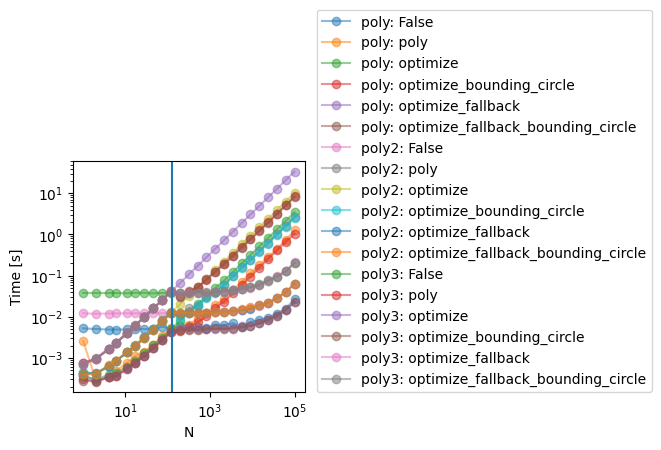

In [11]:
f, ax = plt.subplots()
f.set_size_inches(3,3)

for pol in polys:
# for pol in polys[1:2]:
    for case in results[pol.name]:
        ax.plot(
            results[pol.name][case]['N'],
            results[pol.name][case]['times'],
            'o-',
            label=f"{pol.name}: {case}",
            alpha=0.5,
        )

ax.axvline(x=125)
        
ax.legend(loc=(1.05,0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N')
_ = ax.set_ylabel('Time [s]')

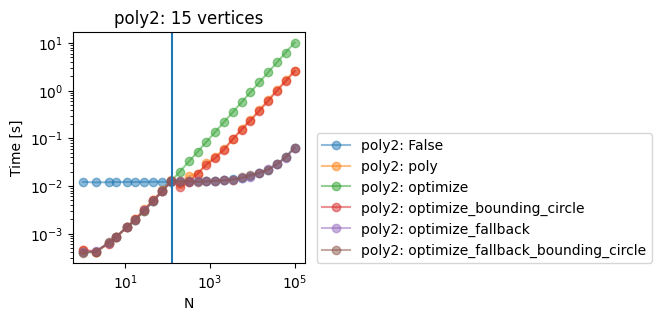

In [12]:
f, ax = plt.subplots()
f.set_size_inches(3,3)

# for pol in polys:
for pol in polys[1:2]:
    for case in results[pol.name]:
        ax.plot(
            results[pol.name][case]['N'],
            results[pol.name][case]['times'],
            'o-',
            label=f"{pol.name}: {case}",
            alpha=0.5,
        )

ax.axvline(x=125)
        
ax.legend(loc=(1.05,0))
ax.set_title(f"{pol.name}: {len(pol.vertices)} vertices")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N')
_ = ax.set_ylabel('Time [s]')

## All points contained within region

In [13]:
results = {}

ra = poly.centroid.ra.value
dec = poly.centroid.dec.value

poly.name = "poly"
poly2.name = "poly2"
poly3.name = "poly3"

polys = [poly, poly2, poly3]
use_sph_geom_vals = [False, "poly", "optimize", "optimize_bounding_circle", "optimize_fallback",
                    "optimize_fallback_bounding_circle"]
N_scaling = np.unique(np.array(np.logspace(0,5, num=25), dtype=int))

for pol in polys:
    results[pol.name] = {}
    for use_sph_geom_type in use_sph_geom_vals:
        kwargs = {'use_sph_geom_type': use_sph_geom_type}
    
        times = []
        for N in N_scaling:
            lons = np.repeat(ra, N)
            lats = np.repeat(dec, N)

            # lons = np.random.randn(N)*1 + ra
            # lats = np.random.randn(N)*1 + dec
            coo = SkyCoord(lons * u.deg, lats*u.deg)
            
            delta, result = my_timeit(pol.contains, coo, **kwargs)

            # # TEST ALL ARE CONTAINED:
            # if np.sum(result) != N:
            #     raise ValueError

            if delta is not None:
                times.append(delta.total_seconds())
            else:
                times.append(np.nan)
    
        results[pol.name][use_sph_geom_type] = {
            'N': N_scaling,
            'times': times
        }

In [14]:
np.sum(result) / len(coo)

np.float64(1.0)

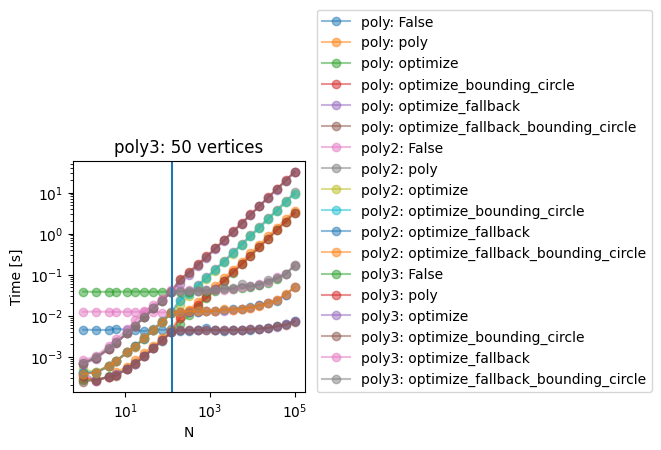

In [15]:
f, ax = plt.subplots()
f.set_size_inches(3,3)

for pol in polys:
    for case in results[pol.name]:
        ax.plot(
            results[pol.name][case]['N'],
            results[pol.name][case]['times'],
            'o-',
            label=f"{pol.name}: {case}",
            alpha=0.5,
        )

ax.axvline(x=125)
        
ax.legend(loc=(1.05,0))
ax.set_title(f"{pol.name}: {len(pol.vertices)} vertices")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N')
_ = ax.set_ylabel('Time [s]')

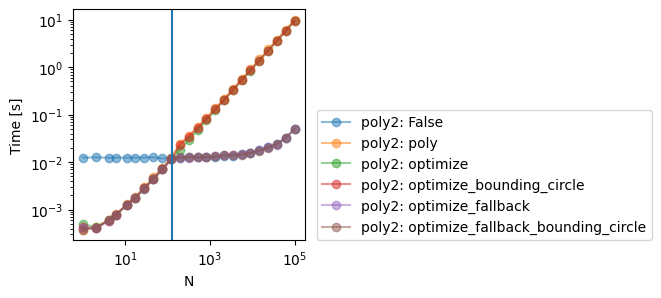

In [16]:
f, ax = plt.subplots()
f.set_size_inches(3,3)

# for pol in polys:
for pol in polys[1:2]:
    for case in results[pol.name]:
        ax.plot(
            results[pol.name][case]['N'],
            results[pol.name][case]['times'],
            'o-',
            label=f"{pol.name}: {case}",
            alpha=0.5,
        )

ax.axvline(x=125)
        
ax.legend(loc=(1.05,0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N')
_ = ax.set_ylabel('Time [s]')